# Configuration

In [1]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

In [2]:
from scipy.stats import norm

# estimators
from econml.grf import CausalForest

# numerical calculation
from scipy.integrate import quad 

In [3]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Estimators

In [5]:
class RandomVariable(object):
    def sample(self, size: int):
        raise NotImplementedError()
    
    def cdf(self, x: float):
        """ 
        Cumulative distribution function
        """
        raise NotImplementedError()

class ContinuousRandomVariable(RandomVariable): 
    def pdf(self, x: float):
        """
        Probability density function (might not exist for some distributions)
        """
        raise NotImplementedError()
    
class DiscreteRandomVariable(RandomVariable): 
    def pmf(self, x: float):
        """ 
        Probability mass function
        """
        raise NotImplementedError()
    
class UnivariateGaussian(ContinuousRandomVariable):
    def __init__(self, mean: float, std: float):
        self.mean = mean
        self.std = std
    
    def sample(self, size: int):
        return np.random.normal(self.mean, self.std, size)
    
    def pdf(self, x: float):
        return norm.pdf(x, self.mean, self.std)

    def cdf(self, x: float):
        return norm.cdf(x, self.mean, self.std)
    
class UnivariateExponential(ContinuousRandomVariable):
    def __init__(self, rate: float):
        self.rate = rate
    
    def sample(self, size: int):
        return np.random.exponential(1 / self.rate, size)
    
    def pdf(self, x: float):
        return self.rate * np.exp(-self.rate * x)
    
    def cdf(self, x: float):
        return 1 - np.exp(-self.rate * x)
    

class Bernoulli(DiscreteRandomVariable):
    def __init__(self, p: float):
        self.p = p
    
    def sample(self, size: int):
        return np.random.binomial(1, self.p, size)
    
    def pmf(self, x: float):        
        if x == 1:
            return self.p
        elif x == 0:
            return 1 - self.p
        else:
            return 0
    
    def cdf(self, x: float):
        if x < 0:
            return 0
        elif x == 0:
            return 1 - self.p
        elif x < 1:
            return 1 - self.p
        else: 
            return 1

In [6]:
# naive estimator
def naive_estimator(data: list):
    """ 
    maximum over the average of the variables
    """
    return max([sample.mean() for sample in data])

# bootstrap estimator
def bootstrap_estimator(data: list, num_bootstraps: int = 5000):
    """
    bootstrap the estimator
    """
    # bootstrapping
    bootstraps = pd.DataFrame({f'var{idx}': np.random.choice(value, size=num_bootstraps) for idx, value in enumerate(data)})
    return bootstraps.max(axis=1).mean()


# Estimating the expected maximum of random variables

## Independent variables

In [47]:
random_variable_meta = [
    {
        'variable': UnivariateGaussian(mean=3, std=2),
        'sample_size': 10
    }, 
    {
        'variable': UnivariateGaussian(mean=2, std=1),
        'sample_size': 20
    }, 
    {
        'variable': UnivariateGaussian(mean=1, std=10),
        'sample_size': 10
    }, 
    {
        'variable': UnivariateExponential(rate=1),
        'sample_size': 50
    }, 
    {
        'variable': UnivariateExponential(rate=0.5), 
        'sample_size': 5
    }, 
]


# sample from meta
data = [dict_['variable'].sample(dict_['sample_size']) for dict_ in random_variable_meta]

def pdf(x, meta: list): 
    result_arr = np.zeros(shape=(len(meta),))
    var_list = [item['variable'] for item in meta]

    for idx in range(len(var_list)):
        result_arr[idx] = var_list[idx].pdf(x) * np.prod([var.cdf(x) for j, var in enumerate(var_list) if j != idx])

    return np.sum(result_arr)

true_mean = quad(lambda x: x * pdf(x, random_variable_meta), -500, 500)[0]

In [48]:
def unbiased_estimator(data):
    var_list = [None for _ in range(len(data))]
    
    var_list[0] = UnivariateGaussian(mean=np.mean(data[0]), std=np.std(data[0]))
    var_list[1] = UnivariateGaussian(mean=np.mean(data[1]), std=np.std(data[1]))
    var_list[2] = UnivariateGaussian(mean=np.mean(data[2]), std=np.std(data[2]))
    var_list[3] = UnivariateExponential(rate=1 / np.mean(data[3]))
    var_list[4] = UnivariateExponential(rate=1 / np.mean(data[4]))

    def empirical_pdf(x):
        result_arr = np.zeros(shape=(len(data),))
        for idx in range(len(data)):
            result_arr[idx] = var_list[idx].pdf(x) * np.prod([var.cdf(x) for j, var in enumerate(var_list) if j != idx])
        return np.sum(result_arr)
    
    return quad(lambda x: x * empirical_pdf(x), -500, 500)[0]

  0%|          | 1/1000 [00:00<03:40,  4.53it/s]/var/folders/3l/3v_7k8t579j60k6cv9rj77080000gn/T/ipykernel_37279/161798511.py:50: RuntimeWarning: overflow encountered in exp
  return 1 - np.exp(-self.rate * x)
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/var/folders/3l/3v_7k8t579j60k6cv9rj77080000gn/T/ipykernel_37279/161798511.py:47: RuntimeWarning: overflow encountered in exp
  return self.rate * np.exp(-self.rate * x)
/var/folders/3l/3v_7k8t579j60k6cv9rj77080000gn/T/ipykernel_37279/1226402653.py:13: RuntimeWarning: invalid value encountered in scalar multiply
  result_arr[idx] = var_list[idx].pdf(x) * np.prod([var.cdf(x) for j, var in enumerate(var_list) if j != idx])
/var/folders/3l/3v_7k8t579j60k6cv9rj77080000gn/T/ipykernel_37279/1226402653.py:16: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If in

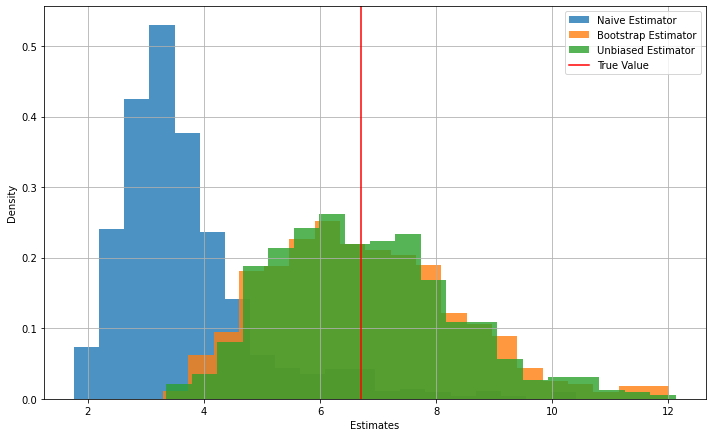

True valueL 6.7120


,Naive Estimator,unbiased Estimator,Bootstrap Estimator
count,1000.000000,958.000000,1000.000000
mean,3.682883,6.758861,6.756297
std,1.270786,1.544355,1.624551
min,1.762616,3.352177,3.292085
25%,2.878326,5.584321,5.568377
50%,3.392551,6.669297,6.604168
75%,4.049662,7.720305,7.773970
max,10.412043,12.127898,12.019435


In [49]:
num_repeats = 1000
naive_estimates_arr = np.zeros(num_repeats)
unbiased_estimates_arr = np.zeros(num_repeats)
bootstrap_estimates_arr = np.zeros(num_repeats)

for repeat_idx in tqdm(range(num_repeats)):
    # sample from meta
    data = [dict_['variable'].sample(dict_['sample_size']) for dict_ in random_variable_meta]

    # calculate the mean 
    naive_estimates_arr[repeat_idx] = naive_estimator(data)
    unbiased_estimates_arr[repeat_idx] = unbiased_estimator(data)
    bootstrap_estimates_arr[repeat_idx] = bootstrap_estimator(data)

# plot the results
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

ax.hist(naive_estimates_arr, bins=20, alpha=0.8, label='Naive Estimator', density=True)
ax.hist(bootstrap_estimates_arr, bins=20, alpha=0.8, label='Bootstrap Estimator', density=True)
ax.hist(unbiased_estimates_arr, bins=20, alpha=0.8, label='Unbiased Estimator', density=True)

ax.axvline(true_mean, color='red', label='True Value')
ax.set_xlabel('Estimates')
ax.set_ylabel('Density')

plt.tight_layout()
plt.legend()
plt.grid()
plt.show()

print(f'True valueL {true_mean:.4f}')
pd.DataFrame({
    'Naive Estimator': naive_estimates_arr, 
    'unbiased Estimator': unbiased_estimates_arr,
    'Bootstrap Estimator': bootstrap_estimates_arr
}).describe()

## Dependent variables

In [42]:
random_variable_meta = [
    {
        'variable': UnivariateGaussian(mean=3, std=2),
        'sample_size': 100
    }, 
    {
        'variable': UnivariateGaussian(mean=2, std=1),
        'sample_size': 200
    }, 
    {
        'variable': UnivariateGaussian(mean=1, std=10),
        'sample_size': 100
    }, 
    {
        'variable': UnivariateExponential(rate=1),
        'sample_size': 500
    }, 
    {
        'variable': UnivariateExponential(rate=0.5), 
        'sample_size': 50
    }, 
]
common_variable = UnivariateGaussian(mean=1, std=1)

# sample from meta
common_variable_sample = common_variable.sample(max([dict_['sample_size'] for dict_ in random_variable_meta]))
data = [dict_['variable'].sample(dict_['sample_size']) + common_variable_sample[:dict_['sample_size']] for dict_ in random_variable_meta]

# calculate the mean 
def calculate_mean(meta: dict, sample_size: int = 500000) -> float: 
    sample_arr = np.zeros(sample_size)
    common_variable_sample = common_variable.sample(sample_size)
    for i in range(sample_size):
        sample_arr[i] = max([var['variable'].sample(1)[0] + common_variable_sample[i] for var in meta])

    return np.mean(sample_arr)
true_mean = calculate_mean(random_variable_meta)

100%|██████████| 1000/1000 [00:00<00:00, 1827.66it/s]


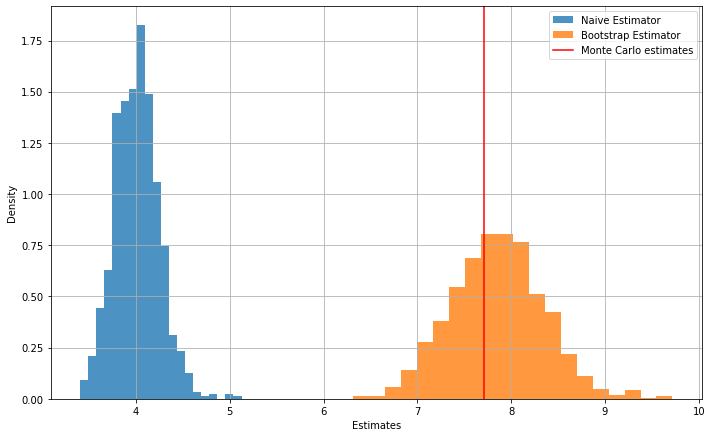

True valueL 7.7096


,Naive Estimator,Bootstrap Estimator
count,1000.000000,1000.000000
mean,4.010249,7.850431
std,0.233942,0.491089
min,3.404368,6.314802
25%,3.844379,7.517832
50%,4.010196,7.851473
75%,4.154299,8.167954
max,5.124585,9.718940


In [43]:
num_repeats = 1000 
naive_estimates_arr = np.zeros(num_repeats)
bootstrap_estimates_arr = np.zeros(num_repeats)

for repeat_idx in tqdm(range(num_repeats)):
    # sample from meta
    common_variable_sample = common_variable.sample(max([dict_['sample_size'] for dict_ in random_variable_meta]))
    data = [dict_['variable'].sample(dict_['sample_size']) + common_variable_sample[:dict_['sample_size']] for dict_ in random_variable_meta]

    # calculate the mean 
    naive_estimates_arr[repeat_idx] = naive_estimator(data)
    bootstrap_estimates_arr[repeat_idx] = bootstrap_estimator(data)

# plot the results
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

ax.hist(naive_estimates_arr, bins=20, alpha=0.8, label='Naive Estimator', density=True)
ax.hist(bootstrap_estimates_arr, bins=20, alpha=0.8, label='Bootstrap Estimator', density=True)

ax.axvline(true_mean, color='red', label='Monte Carlo estimates')
ax.set_xlabel('Estimates')
ax.set_ylabel('Density')

plt.tight_layout()
plt.legend()
plt.grid()
plt.show()

print(f'True valueL {true_mean:.4f}')
pd.DataFrame({
    'Naive Estimator': naive_estimates_arr, 
    'Bootstrap Estimator': bootstrap_estimates_arr
}).describe()

# Sketch

In [38]:
normal1 = UnivariateGaussian(mean=1, std=2)
normal2 = UnivariateGaussian(mean=2, std=3)

pdf = lambda x: normal1.pdf(x) * normal2.cdf(x) + normal1.cdf(x) * normal2.pdf(x) 

true_mean = quad(lambda x: x * pdf(x), -np.inf, np.inf)[0]

In [39]:
random_variable_meta = [
    {
        'variable': UnivariateGaussian(mean=1, std=2),
        'sample_size': 100
    }, 
    {
        'variable': UnivariateGaussian(mean=2, std=3),
        'sample_size': 200
    }, 
]

# sample from meta
data = [dict_['variable'].sample(dict_['sample_size']) for dict_ in random_variable_meta]

In [40]:
def unbiased_estimator(data): 
    mean1, std1 = np.mean(data[0]), np.std(data[0])
    mean2, std2 = np.mean(data[1]), np.std(data[1])

    empirical_normal1 = UnivariateGaussian(mean=mean1, std=std1)
    empirical_normal2 = UnivariateGaussian(mean=mean2, std=std2)

    empirical_pdf = lambda x: empirical_normal1.pdf(x) * empirical_normal2.cdf(x) + empirical_normal1.cdf(x) * empirical_normal2.pdf(x) 

    return quad(lambda x: x * empirical_pdf(x), -np.inf, np.inf)

100%|██████████| 1000/1000 [01:01<00:00, 16.38it/s]


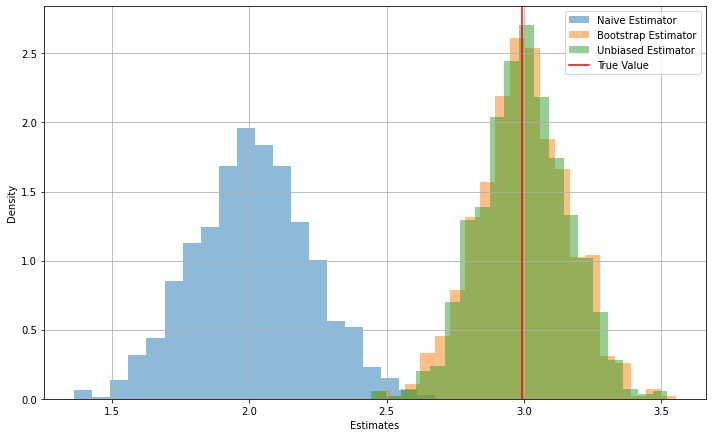

True valueL 2.9934


,Naive Estimator,Unbaised Estimator,Bootstrap Estimator
count,1000.000000,1000.000000,1000.000000
mean,2.011810,2.999765,2.999810
std,0.212677,0.160718,0.164046
min,1.361762,2.443545,2.458850
25%,1.869980,2.894868,2.894397
50%,2.012640,3.001543,2.999752
75%,2.152110,3.105052,3.110503
max,2.677276,3.523155,3.552900


In [41]:
num_repeats = 1000
naive_estimates_arr = np.zeros(num_repeats)
unbiased_estimates_arr = np.zeros(num_repeats)
bootstrap_estimates_arr = np.zeros(num_repeats)

for repeat_idx in tqdm(range(num_repeats)):
    # sample from meta
    data = [dict_['variable'].sample(dict_['sample_size']) for dict_ in random_variable_meta]

    # calculate the mean 
    naive_estimates_arr[repeat_idx] = naive_estimator(data)
    unbiased_estimates_arr[repeat_idx] = unbiased_estimator(data)[0]
    bootstrap_estimates_arr[repeat_idx] = bootstrap_estimator(data)


# plot the results
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

ax.hist(naive_estimates_arr, bins=20, alpha=0.5, label='Naive Estimator', density=True)
ax.hist(bootstrap_estimates_arr, bins=20, alpha=0.5, label='Bootstrap Estimator', density=True)
ax.hist(unbiased_estimates_arr, bins=20, alpha=0.5, label='Unbiased Estimator', density=True)

ax.axvline(true_mean, color='red', label='True Value')

ax.set_xlabel('Estimates')
ax.set_ylabel('Density')

plt.tight_layout()
plt.legend()
plt.grid()
plt.show()

print(f'True valueL {true_mean:.4f}')
pd.DataFrame({
    'Naive Estimator': naive_estimates_arr, 
    'Unbaised Estimator': unbiased_estimates_arr, 
    'Bootstrap Estimator': bootstrap_estimates_arr
}).describe()

Maximum between a Bernoulli and a Normal

$X_1 \sim \mathcal{N}(\mu, \sigma^2)$ and $X_2 \sim B(p)$. $Y = \max\{X_1, X_2\}$. 

The CDF of $Y$ is:

$$
\begin{aligned}
\Pr(Y \leq y) & = \Pr(\max\{X_1, 1\} \leq y) p + \Pr(\max\{X_1, 0\} \leq y) \bar{p} \\ 
& = [\Pr(X_1 \leq 1 \leq y) p + \Pr(1 \leq X_1 \leq y) p] \mathbb{I}\{y \geq 1\}  \\
& \qquad +  [\Pr(X_1 \leq 0 \leq y) \bar{p} + \Pr(0 \leq X_1 \leq y) \bar{p}] \mathbb{I}\{y \geq 0\}\\ 
& = F_1(y)p \mathbb{I}\{y \geq 1\} + F_1(y) \bar{p} \mathbb{I}\{y \geq 0\}\\ 
& = \begin{cases}
F_1(y) & \quad \text{if } y \geq 1 \\ 
F_1(y) \bar{p} & \quad \text{if } 0 \leq y < 1 \\ 
0 & \quad \text{if } y < 0
\end{cases}
\end{aligned}
$$

In [25]:
normal1 = UnivariateGaussian(mean=1, std=2)
bernoulli1 = Bernoulli(p=0.3)

def cdf(x):
    if x >= 1:
        return normal1.cdf(x)
    elif 0 <= x < 1:
        return normal1.cdf(x) * bernoulli1.pmf(0)
    else: 
        return 0

In [26]:
sample_size = 10000

x1_sample = normal1.sample(sample_size)
x2_sample = bernoulli1.sample(sample_size)

y_sample = np.maximum(x1_sample, x2_sample)

In [27]:
y_sample.mean()

1.5154160508188341

In [28]:
quad(lambda x: 1 - cdf(x), 0, np.inf)

(1.5162805486026882, 2.027808514952213e-09)

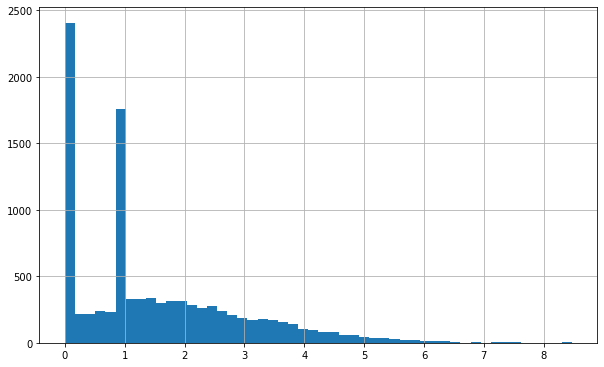

In [29]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

ax.hist(y_sample, bins=50)
ax.set_xticks(np.arange(0, round(np.max(y_sample)) + 1, 1))

plt.grid()
plt.show()